In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
DATA_PATH = "../data/processed/final.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [40]:
df.head()

,listed_in_freq_log,genre_kids,duration,genre_family,country_freq_log,genre_international,release_year,genre_drama,genre_count,director_freq,...,has_kids_words,cast_freq,year_added,month_added,genre_documentaries,description_len,genre_action,cast_count,director_count,rating
0,5.857933,0,90.0,0,8.164795,0,2020,0,1,1,...,0,826,2021,9,1,152,0,1,1,teen
1,3.295837,0,2.0,0,3.433987,1,2021,1,3,2625,...,1,1,2021,9,0,147,0,19,1,adult
2,2.944439,0,1.0,0,8.164795,1,2021,0,3,3,...,1,1,2021,9,0,146,1,9,1,adult
3,2.833213,0,1.0,0,8.164795,0,2021,0,2,2625,...,0,826,2021,9,0,147,0,1,1,adult
4,4.553877,0,2.0,0,6.837333,1,2021,0,3,2625,...,0,1,2021,9,0,152,0,8,1,adult


In [41]:
df.shape

(8535, 31)

In [42]:
df.columns

Index(['listed_in_freq_log', 'genre_kids', 'duration', 'genre_family',
       'country_freq_log', 'genre_international', 'release_year',
       'genre_drama', 'genre_count', 'director_freq', 'is_long_duration',
       'day_added', 'genre_comedy', 'title_len', 'is_movie', 'text_len',
       'genre_romantic', 'has_mature_words', 'genre_crime', 'genre_horror',
       'is_medium_duration', 'has_kids_words', 'cast_freq', 'year_added',
       'month_added', 'genre_documentaries', 'description_len', 'genre_action',
       'cast_count', 'director_count', 'rating'],
      dtype='object')

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8535 entries, 0 to 8534
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   listed_in_freq_log   8535 non-null   float64
 1   genre_kids           8535 non-null   int64  
 2   duration             8535 non-null   float64
 3   genre_family         8535 non-null   int64  
 4   country_freq_log     8535 non-null   float64
 5   genre_international  8535 non-null   int64  
 6   release_year         8535 non-null   int64  
 7   genre_drama          8535 non-null   int64  
 8   genre_count          8535 non-null   int64  
 9   director_freq        8535 non-null   int64  
 10  is_long_duration     8535 non-null   int64  
 11  day_added            8535 non-null   int64  
 12  genre_comedy         8535 non-null   int64  
 13  title_len            8535 non-null   int64  
 14  is_movie             8535 non-null   int64  
 15  text_len             8535 non-null   i

In [44]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

listed_in_freq_log     0
genre_kids             0
duration               0
genre_family           0
country_freq_log       0
genre_international    0
release_year           0
genre_drama            0
genre_count            0
director_freq          0
is_long_duration       0
day_added              0
genre_comedy           0
title_len              0
is_movie               0
text_len               0
genre_romantic         0
has_mature_words       0
genre_crime            0
genre_horror           0
is_medium_duration     0
has_kids_words         0
cast_freq              0
year_added             0
month_added            0
genre_documentaries    0
description_len        0
genre_action           0
cast_count             0
director_count         0
rating                 0
dtype: int64

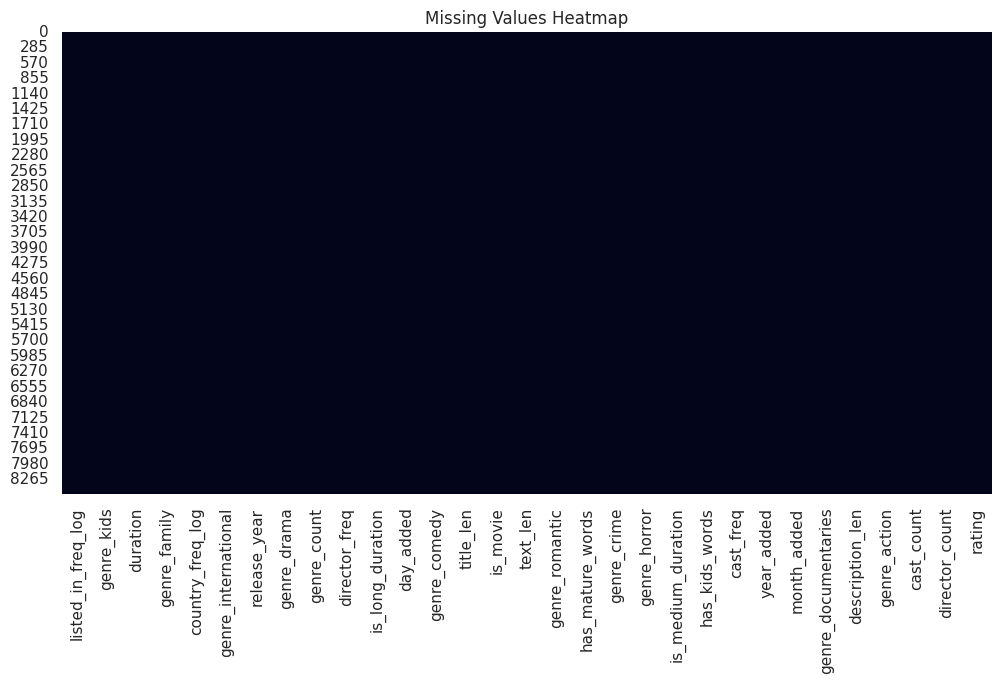

In [45]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
TARGET = "rating" 

df[TARGET].value_counts()

rating
adult    3931
teen     3639
kids      883
other      82
Name: count, dtype: int64

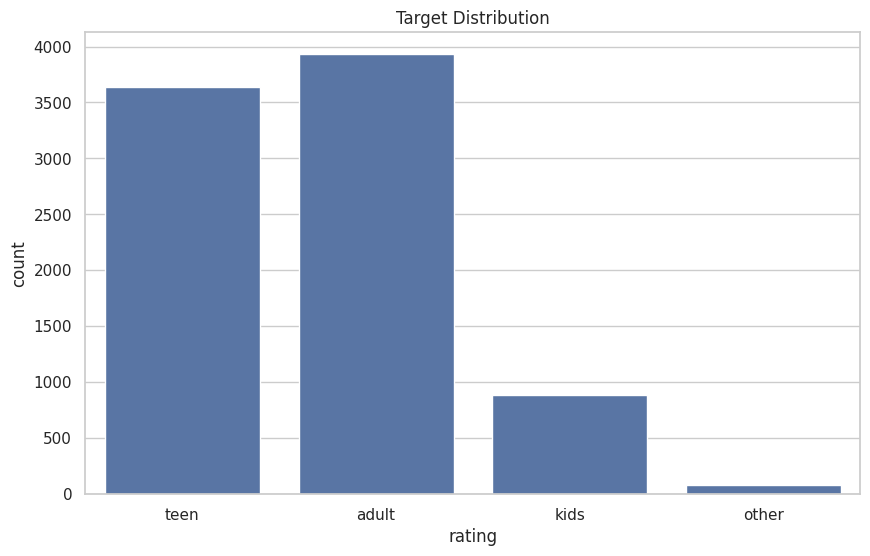

In [48]:
sns.countplot(x=df[TARGET])
plt.title("Target Distribution")
plt.show()

In [49]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

num_cols

['listed_in_freq_log',
 'genre_kids',
 'duration',
 'genre_family',
 'country_freq_log',
 'genre_international',
 'release_year',
 'genre_drama',
 'genre_count',
 'director_freq',
 'is_long_duration',
 'day_added',
 'genre_comedy',
 'title_len',
 'is_movie',
 'text_len',
 'genre_romantic',
 'has_mature_words',
 'genre_crime',
 'genre_horror',
 'is_medium_duration',
 'has_kids_words',
 'cast_freq',
 'year_added',
 'month_added',
 'genre_documentaries',
 'description_len',
 'genre_action',
 'cast_count',
 'director_count']

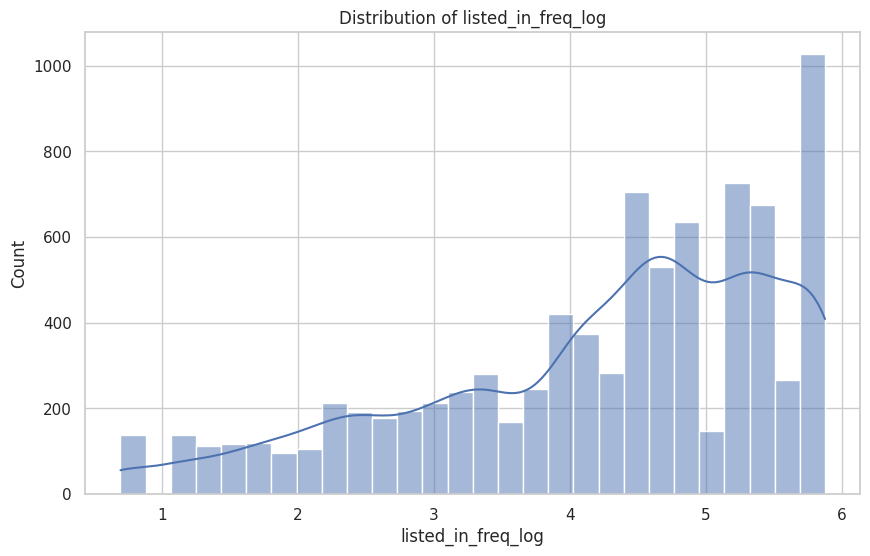

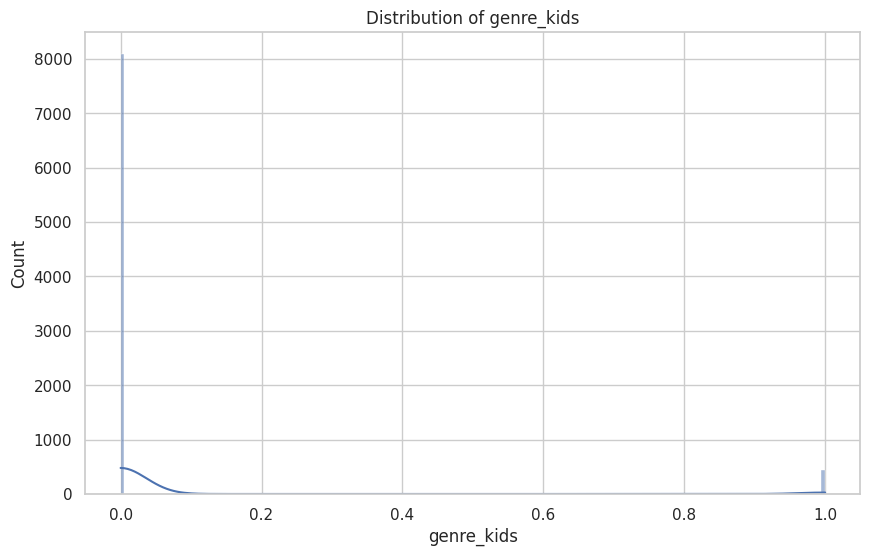

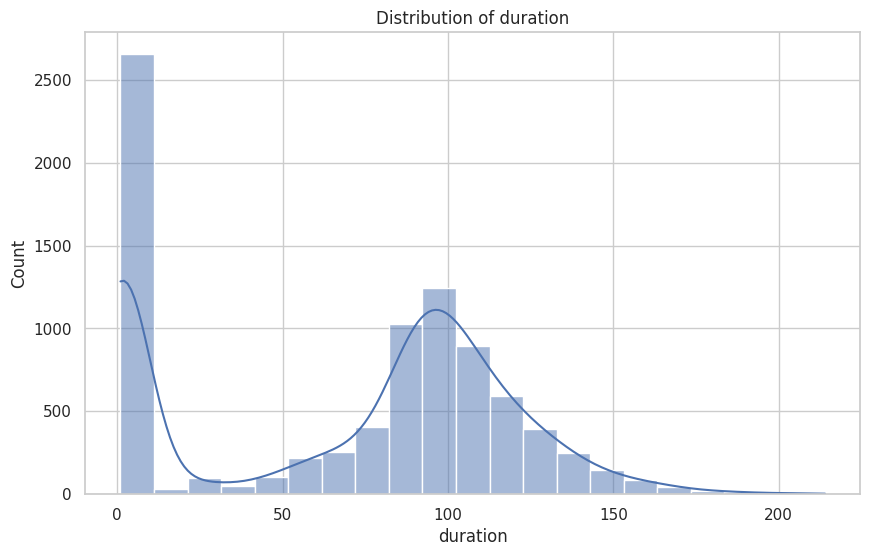

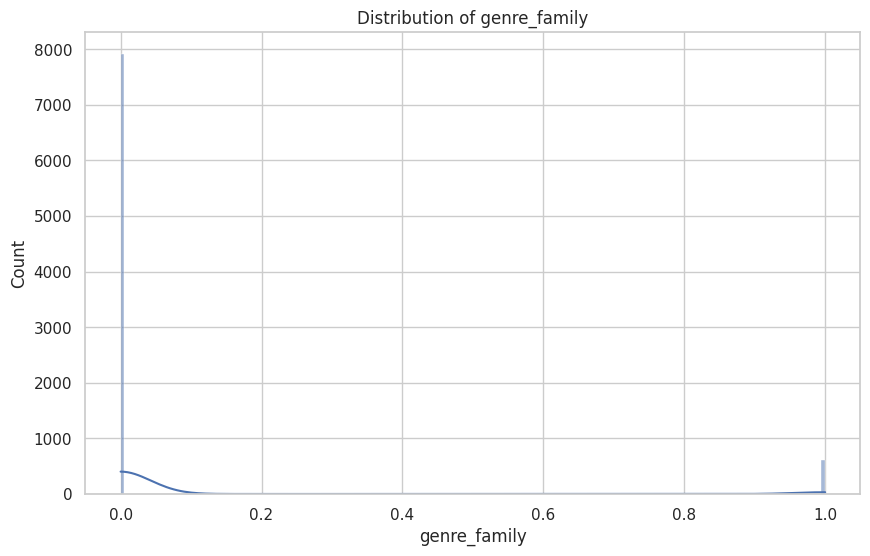

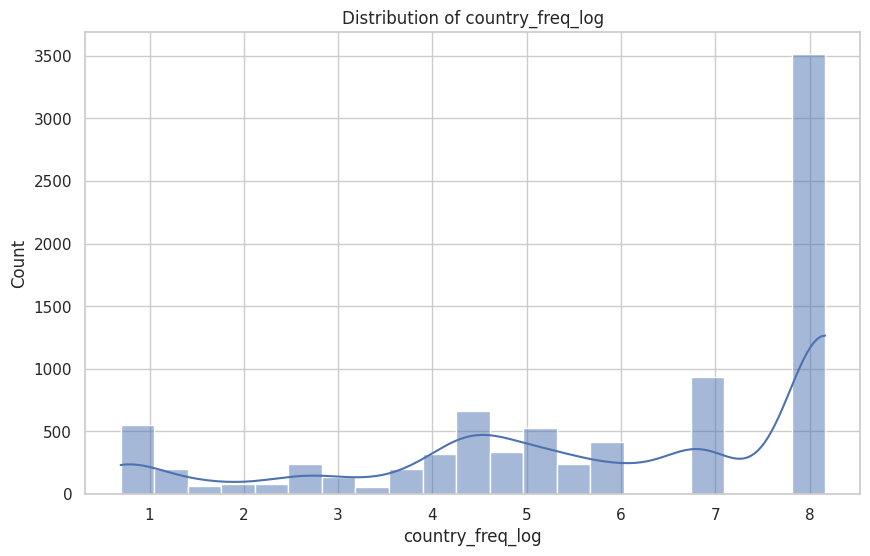

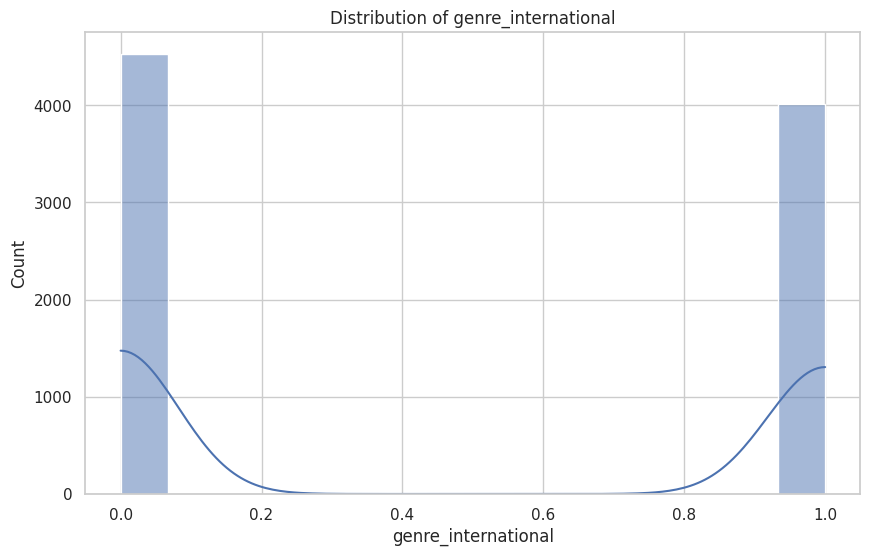

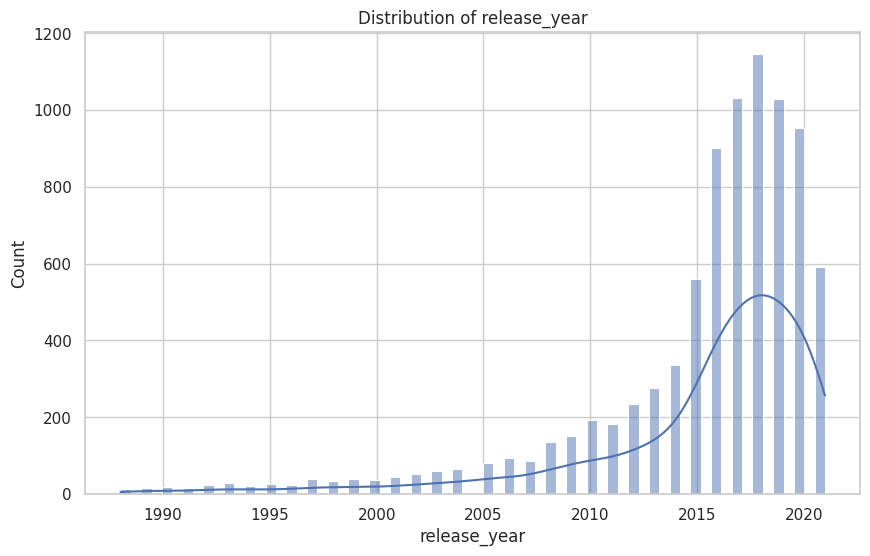

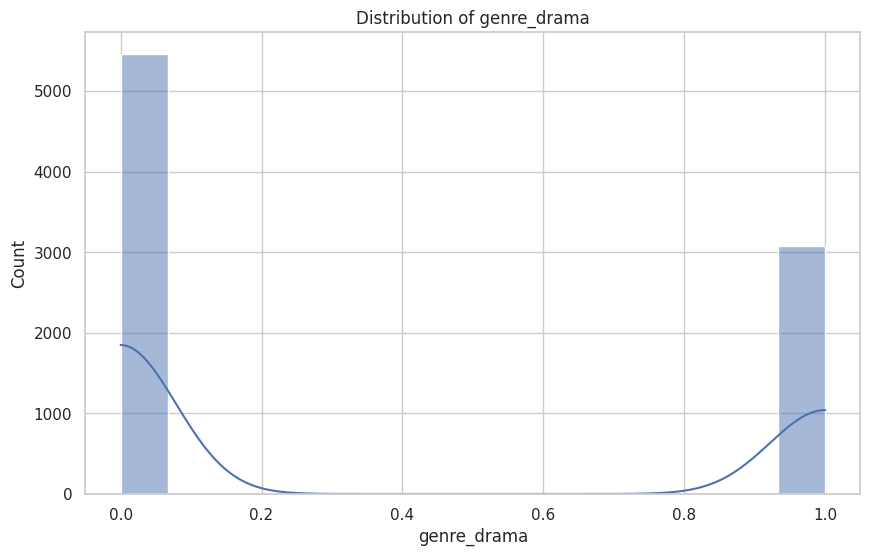

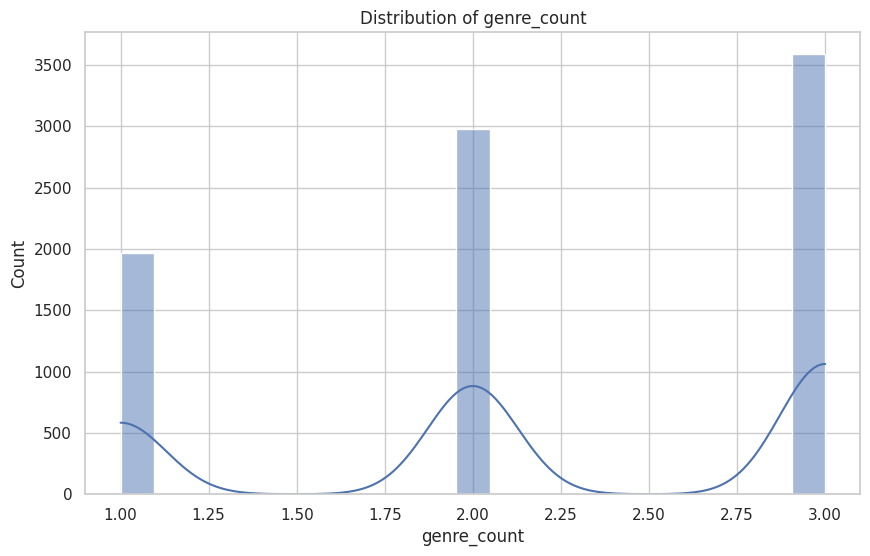

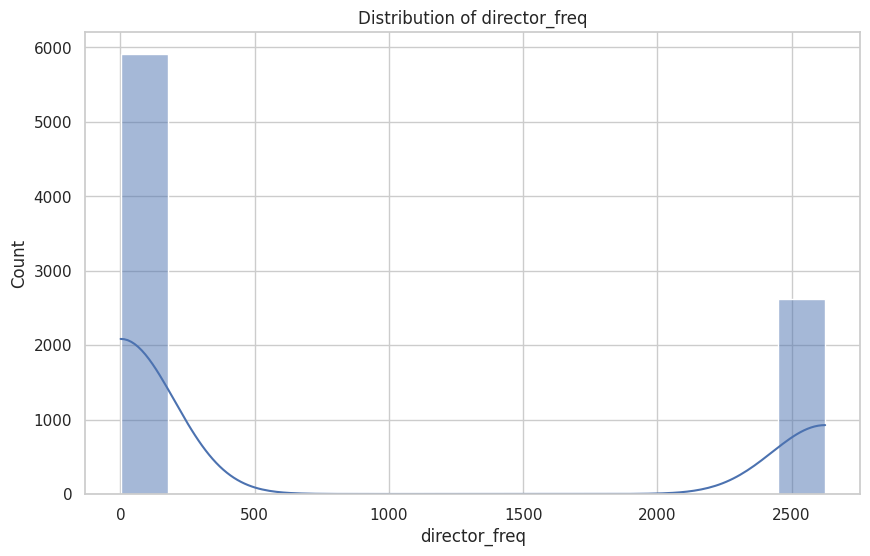

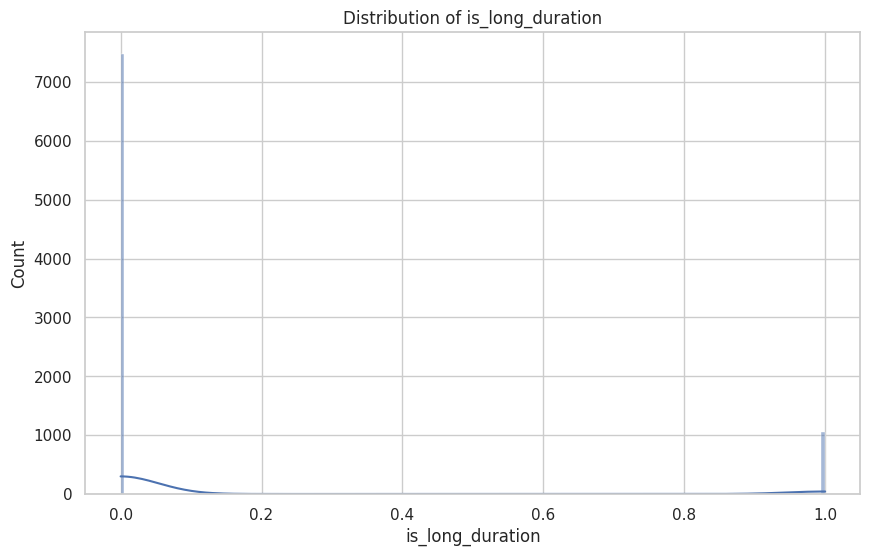

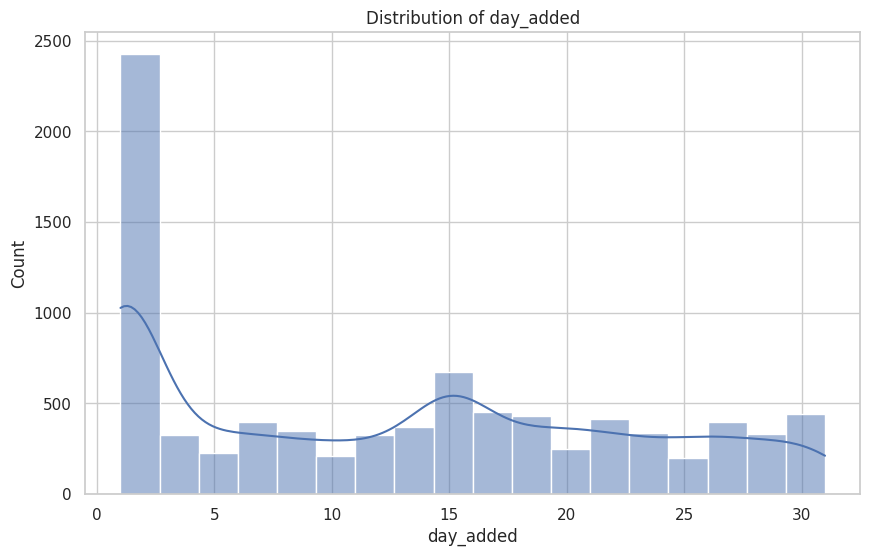

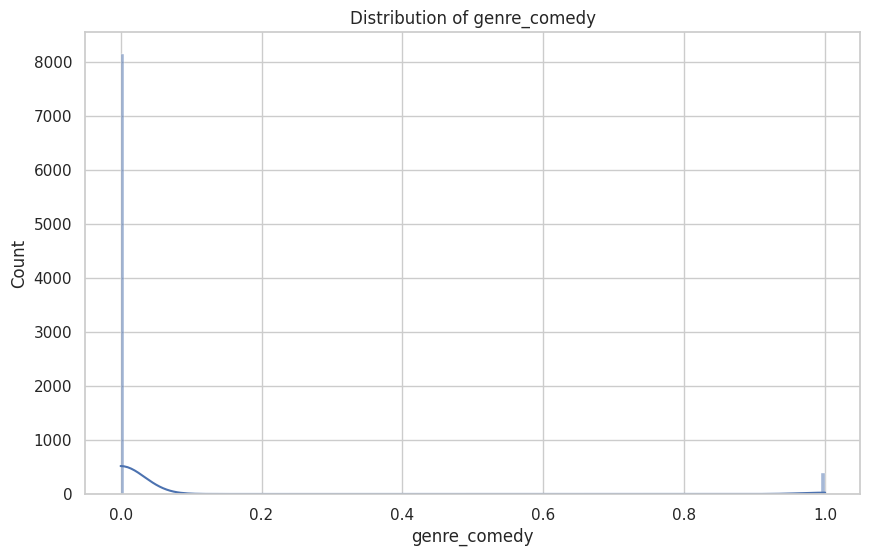

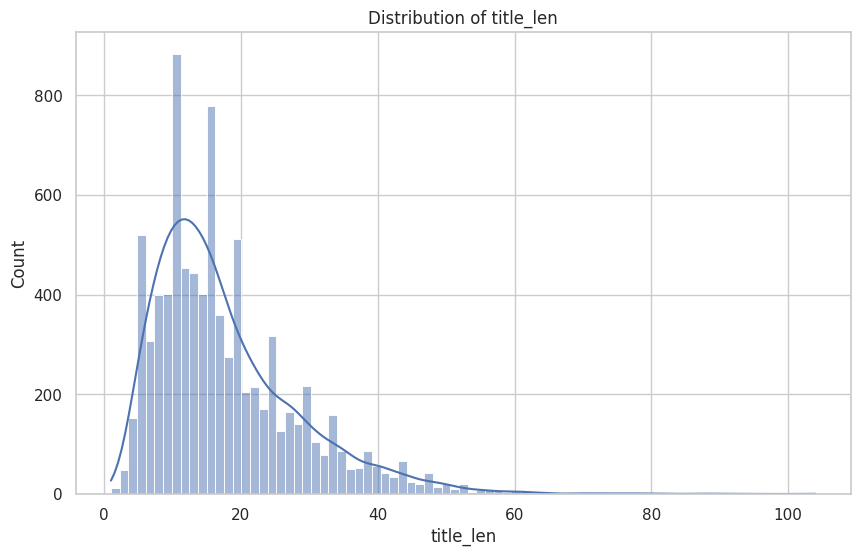

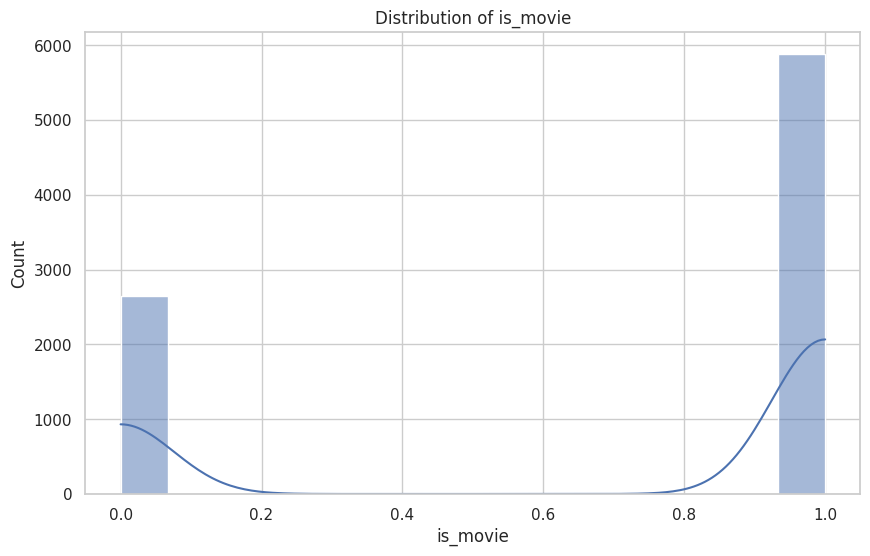

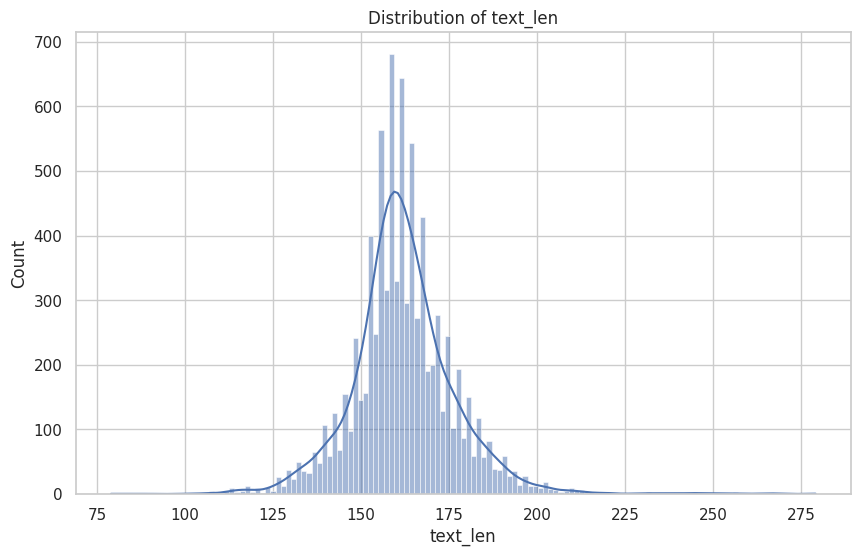

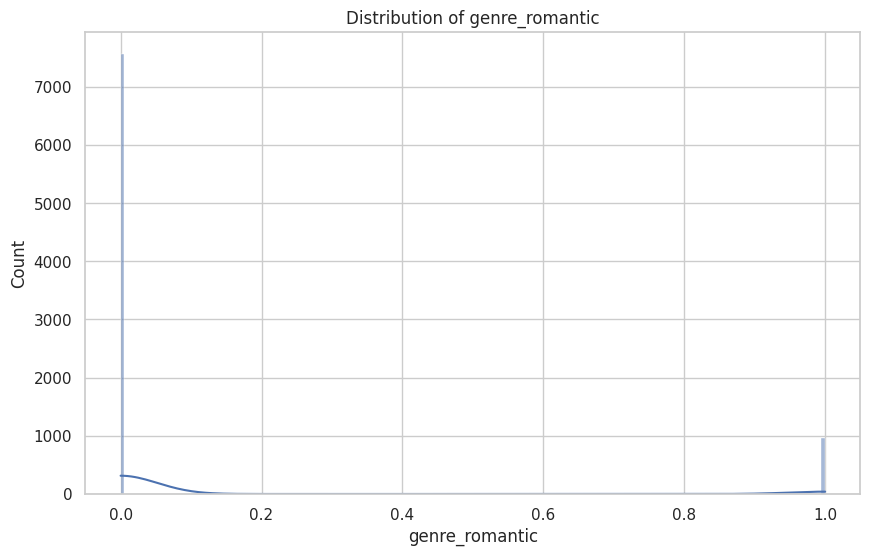

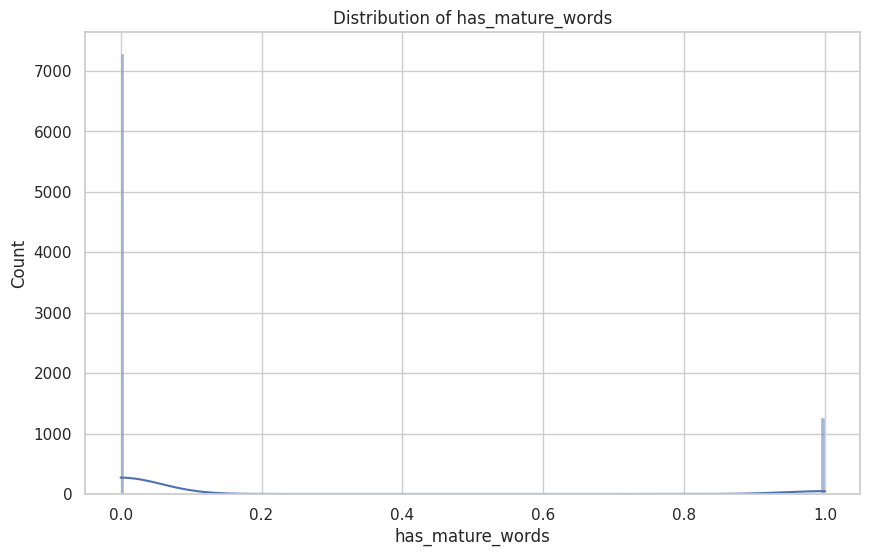

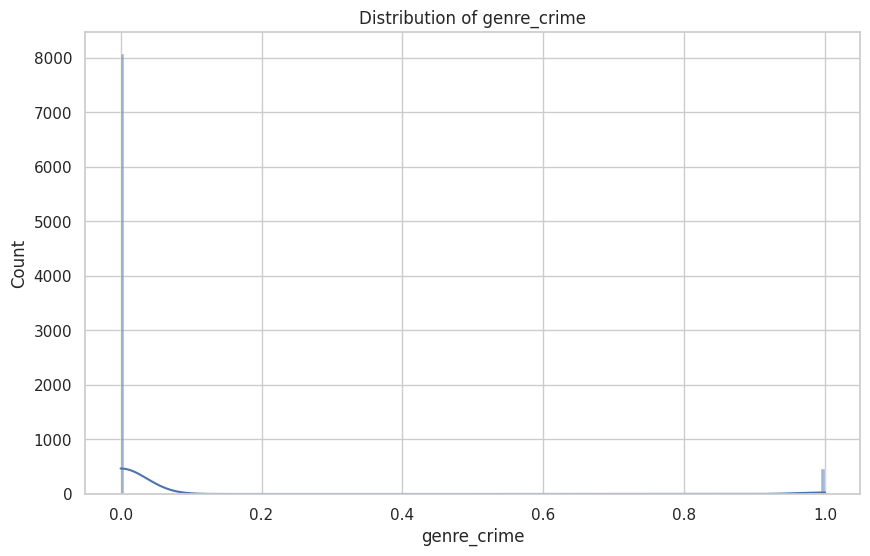

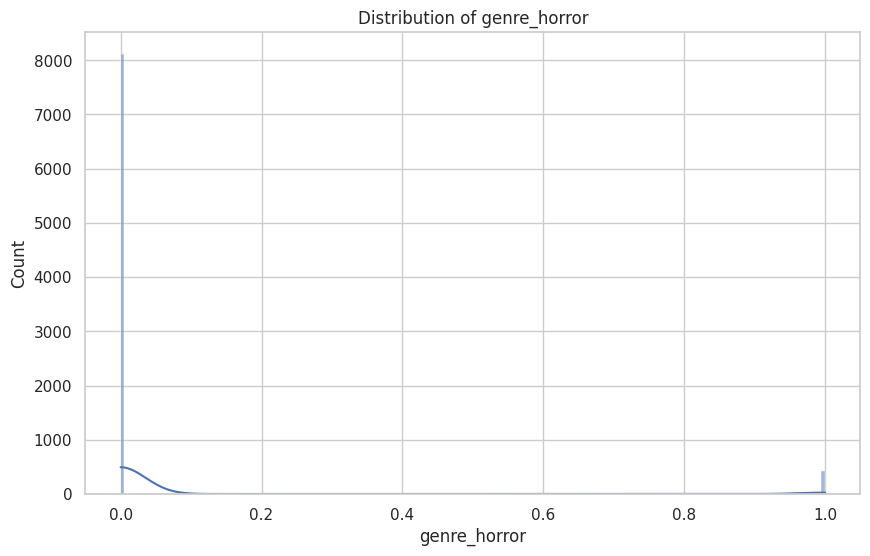

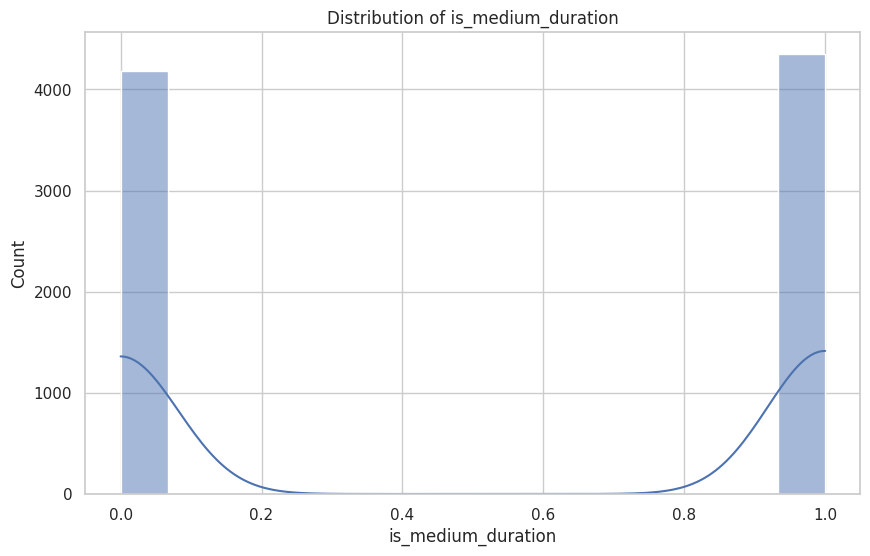

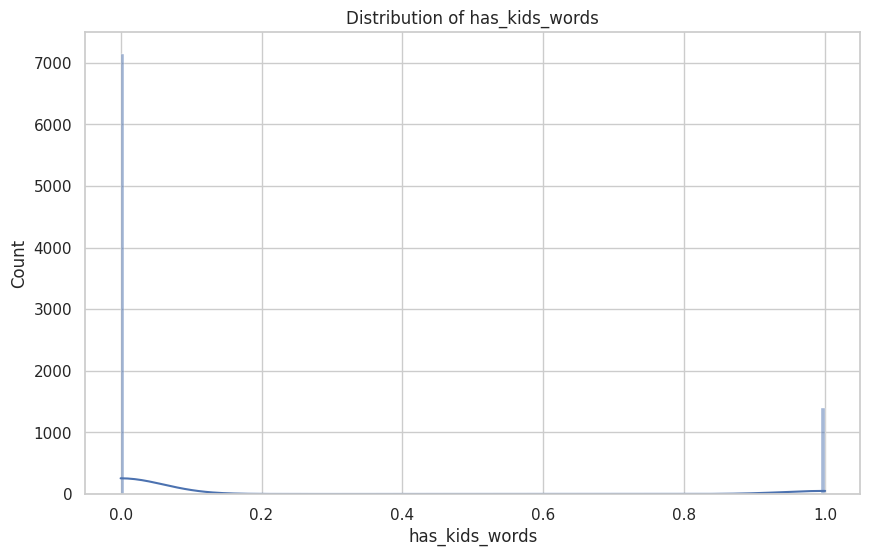

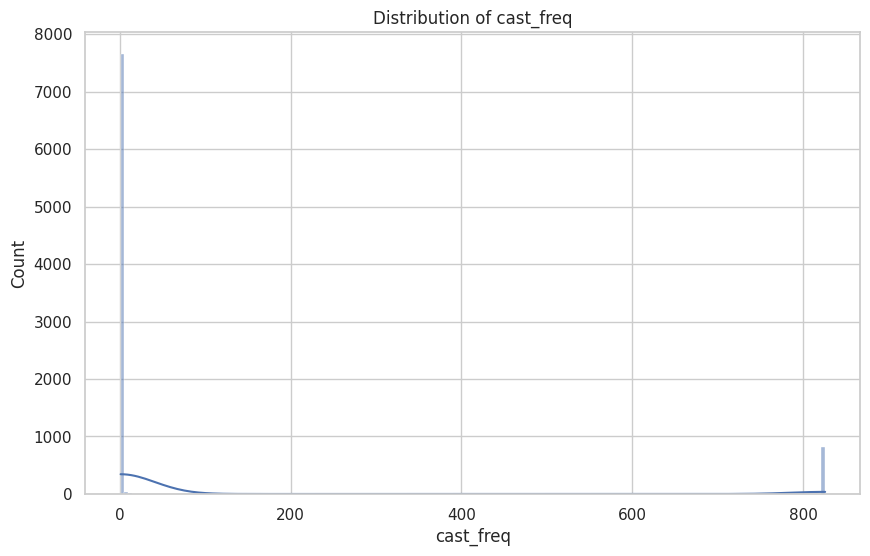

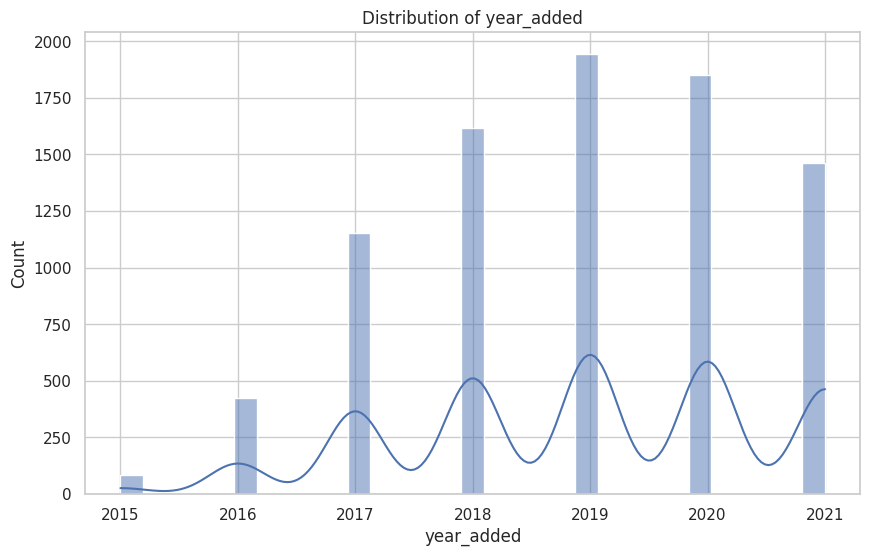

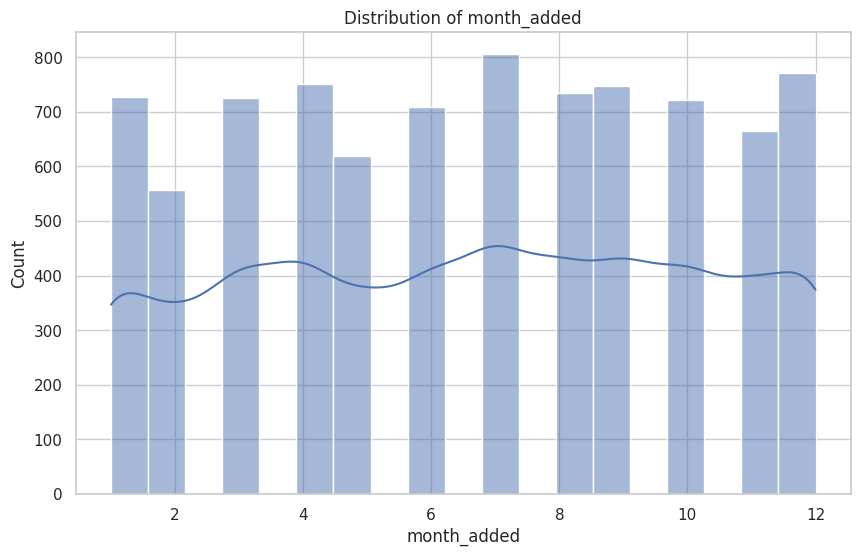

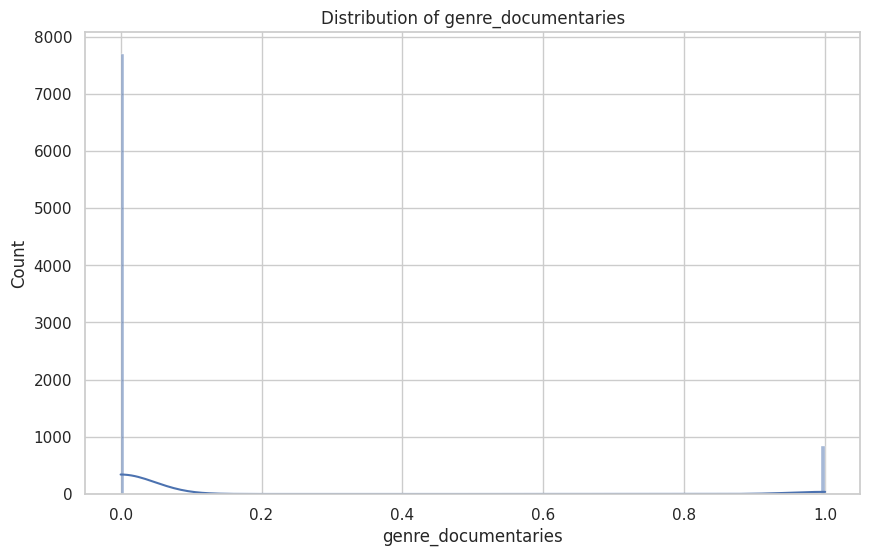

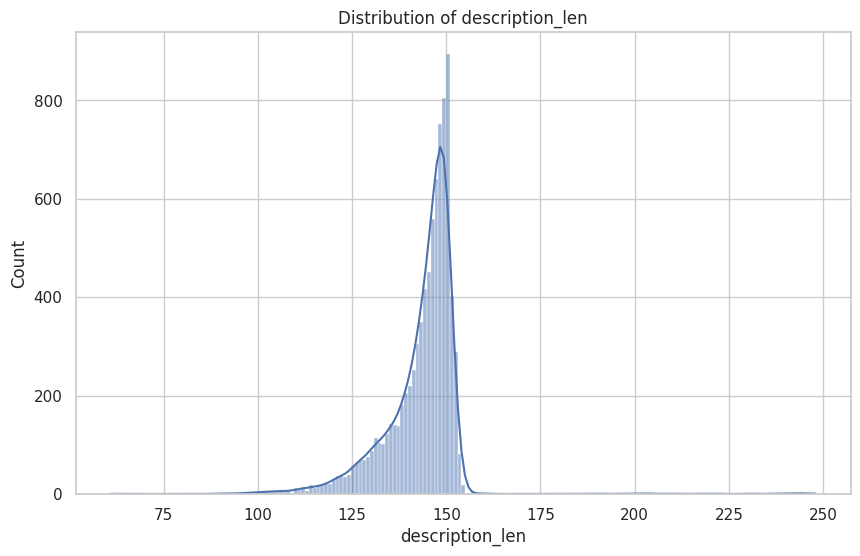

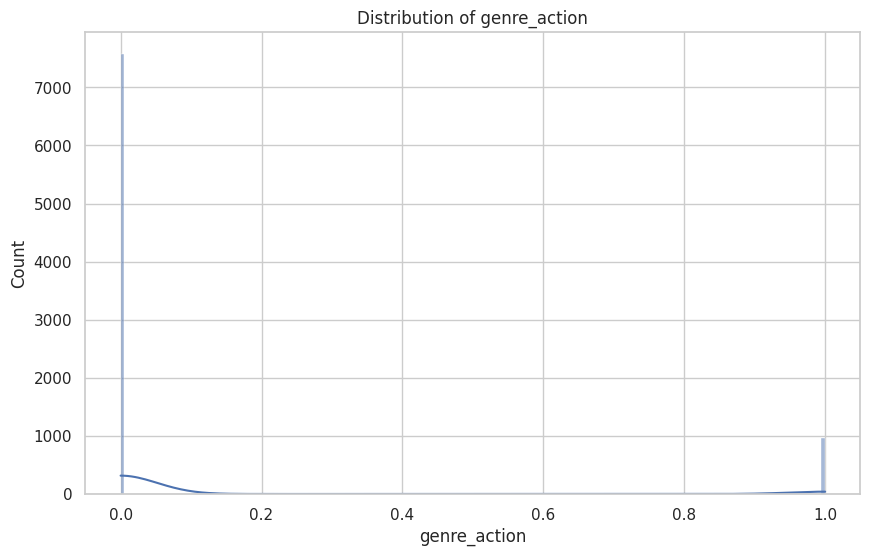

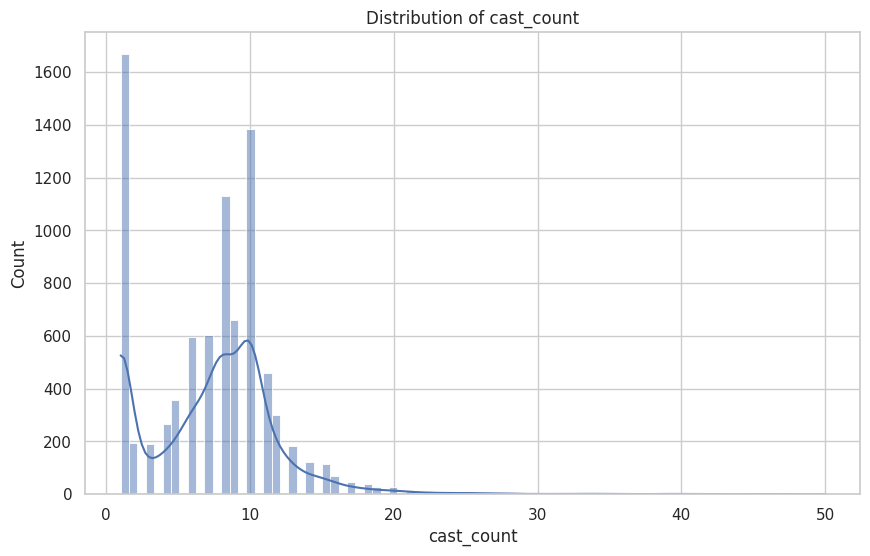

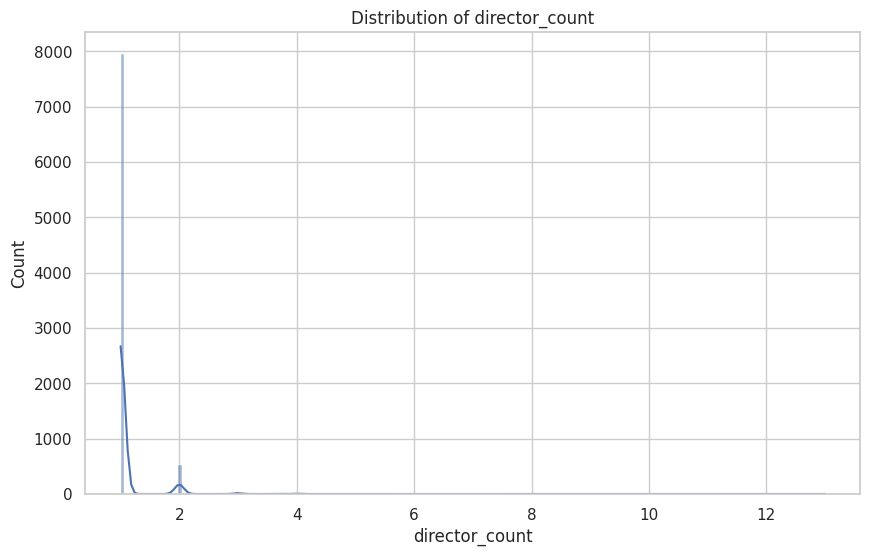

In [50]:
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [21]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

cat_cols

['rating']

In [51]:
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head(10))


Column: rating
rating
adult    3931
teen     3639
kids      883
other      82
Name: count, dtype: int64


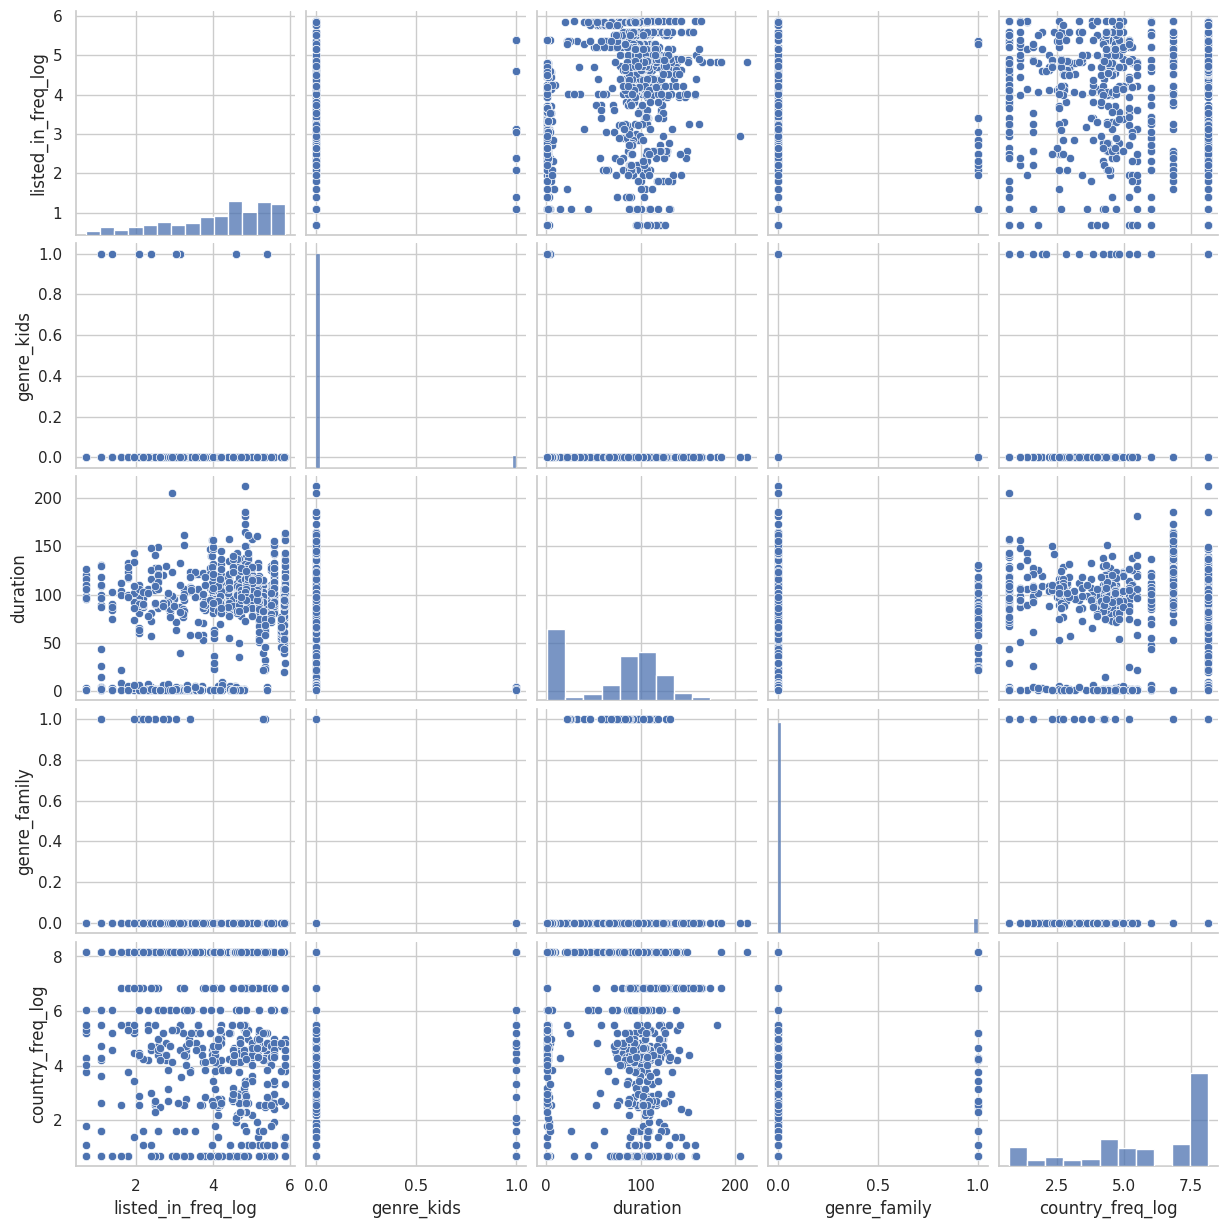

In [52]:
sample_df = df.sample(min(1000, len(df)))

sns.pairplot(sample_df[num_cols[:5]])  # limit for performance
plt.show()

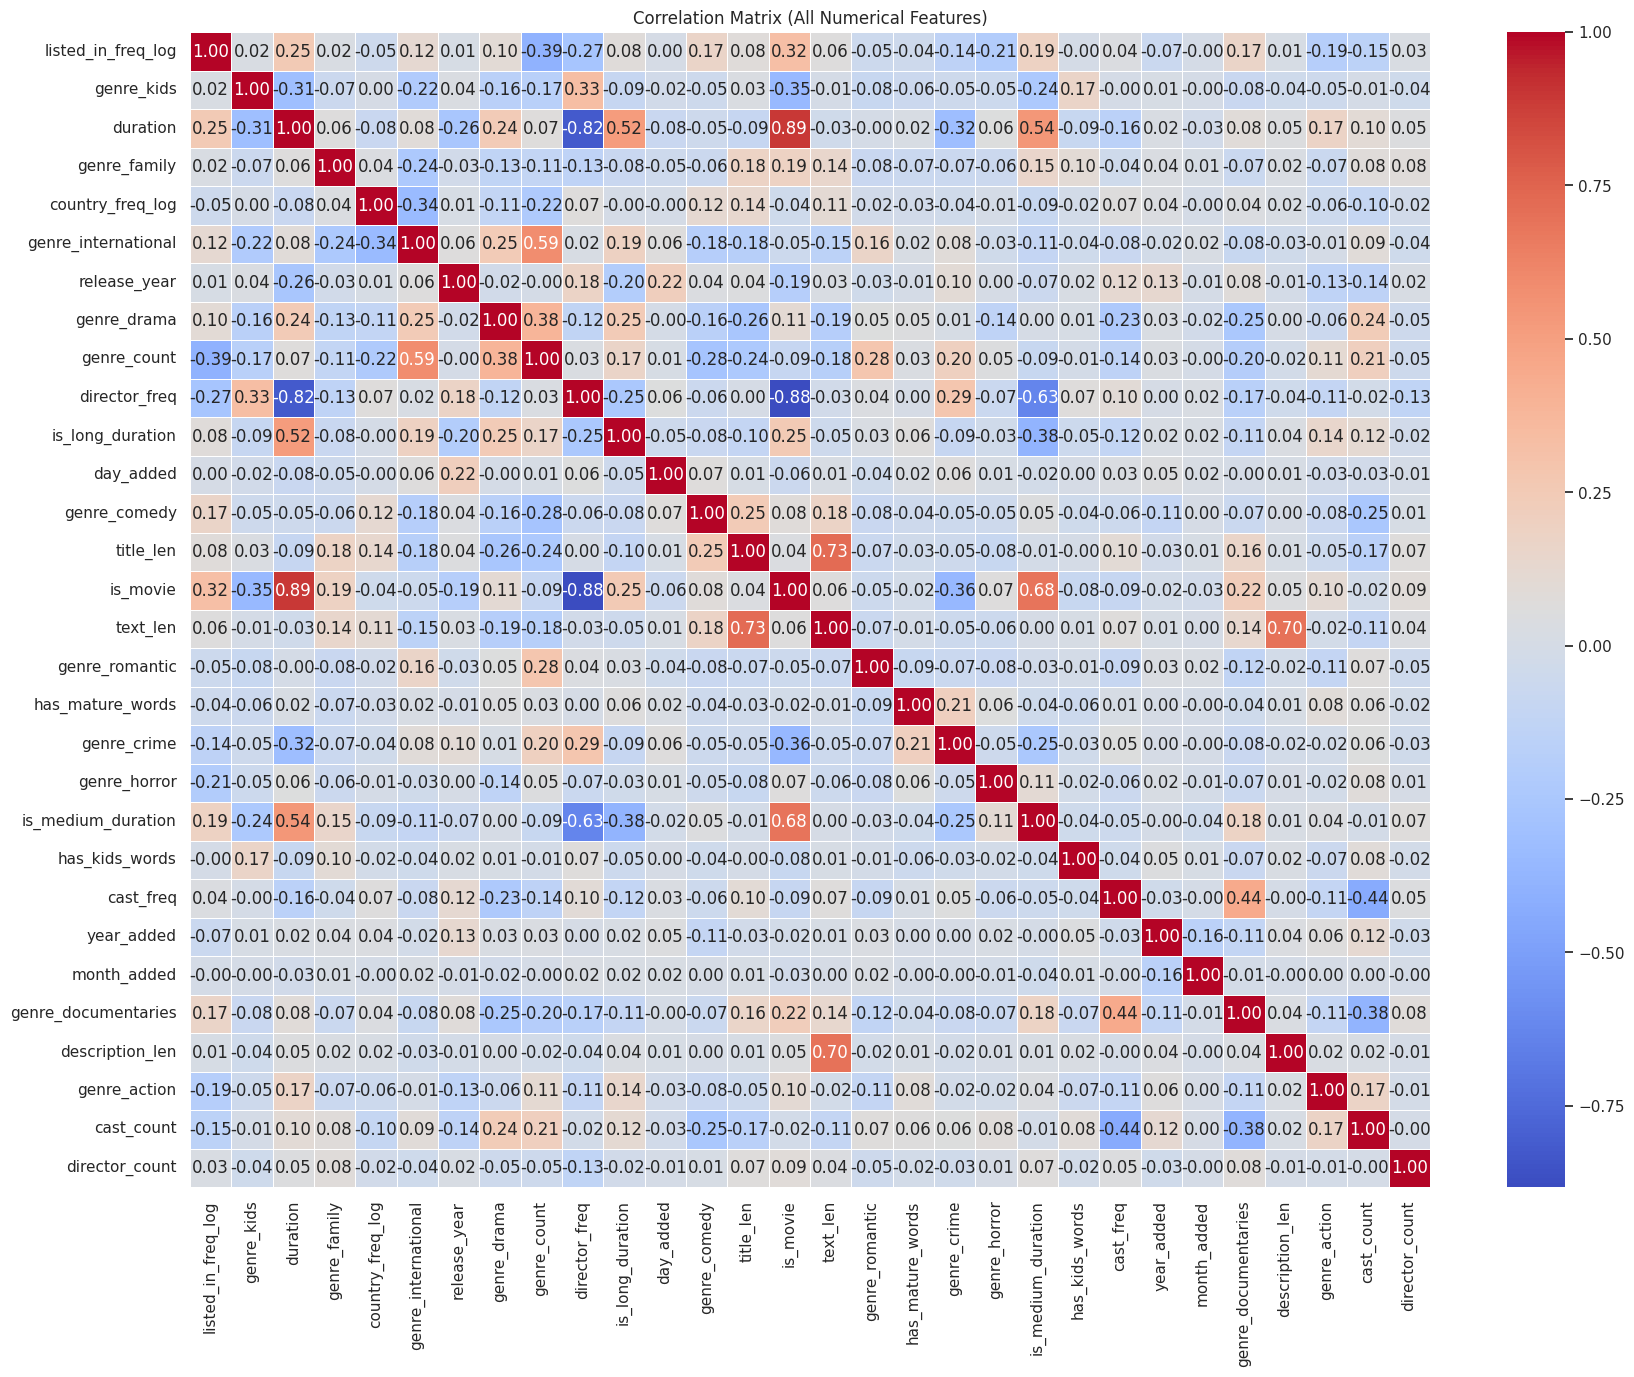

In [53]:

corr = df[num_cols].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix (All Numerical Features)")
plt.show()

In [54]:
high_corr = []

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.8:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

high_corr

[('director_freq', 'duration', np.float64(-0.8212133907135206)),
 ('is_movie', 'duration', np.float64(0.892205973258302)),
 ('is_movie', 'director_freq', np.float64(-0.8823218387167935))]

In [55]:
df[num_cols].skew().sort_values(ascending=False)

director_count         12.819236
genre_comedy            4.384384
genre_horror            4.163068
genre_kids              4.019316
genre_crime             3.916568
genre_family            3.297027
cast_freq               2.728080
genre_documentaries     2.696745
genre_action            2.453462
genre_romantic          2.435010
is_long_duration        2.281002
has_mature_words        1.989684
has_kids_words          1.821825
title_len               1.458881
cast_count              1.270670
description_len         0.864763
director_freq           0.834160
text_len                0.811229
genre_drama             0.582694
day_added               0.289494
genre_international     0.121864
is_medium_duration     -0.039147
month_added            -0.044628
duration               -0.223357
year_added             -0.316779
genre_count            -0.345901
country_freq_log       -0.758770
listed_in_freq_log     -0.780476
is_movie               -0.818139
release_year           -2.044839
dtype: flo